# explore models of the CNN model

In [6]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, f1_score, r2_score
import dtreeviz

%config InlineBackend.figure_format = 'retina' # Make visualizations look good
%matplotlib inline

In [7]:
stats = np.load('../summary_stats/stats_GBR.npy')
preds = np.loadtxt('../predictions/prob_CEU_0_230410_GBR.txt')[:,-1]
preds_sel = np.loadtxt('../predictions/prob_CEU_0_230410_230830_finetuneAug23_GBR.txt')[:,-1]

X = stats
ys = [preds, preds_sel]

In [78]:
stats_orig = [f'SFS_{i}' for i in range(1, 11)] + \
             [f'inter-SNP_{i}' for i in range(1, 37)] + \
             [f'LD_{i}' for i in range(1, 16)] + ['$\pi$', '#haps']

stats_extra = ['ihs_maxabs', "tajimas_d", 'garud_h1', 'garud_h12', 'garud_h123', 'garud_h2_h1']

feature_lst = stats_orig + stats_extra

-------------------- Real Generated --------------------
Mean squared error: 0.000890210809131095
R^2: 0.575107081758275


Accuracy: 0.8100454807969968
F1 score: 0.8145341768136883


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


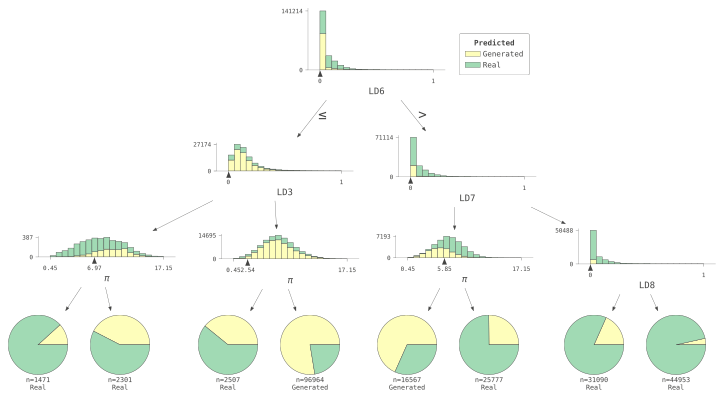

-------------------- Selected Not Selected --------------------
Mean squared error: 0.003335033946371241
R^2: 0.4696297169617035


Accuracy: 0.9901277793820387
F1 score: 0.5896474118529632


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


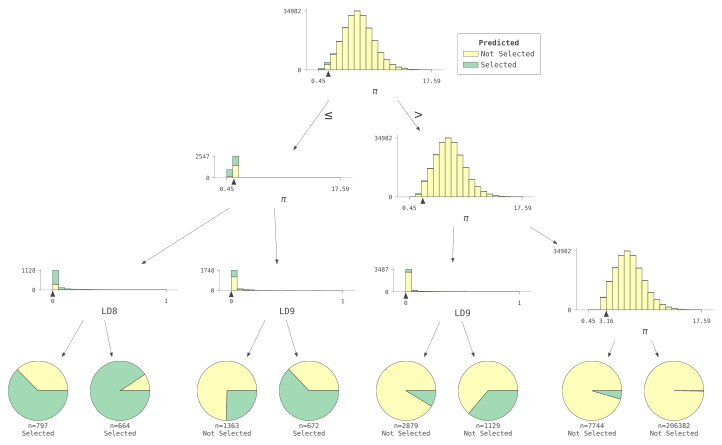

In [9]:
for y, (label1, label2) in zip(ys, [("Real", "Generated"), ("Selected", "Not Selected")]):
    print("-" * 20, label1, label2, "-" * 20)
    # train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    y_train_bool = (y_train > 0.5).astype(int)
    y_test_bool = (y_test > 0.5).astype(int)

    # train model
    # regressor
    model_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
    model_reg.fit(X_train, y_train)

    # classifier
    model_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    model_clf.fit(X_train, y_train_bool)

    # evaluate model
    y_pred = model_reg.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("Mean squared error:", mse)
    print("R^2:", r2)

    viz = dtreeviz.model(model_reg, X_train[:5000], y_train[:5000],
                    target_name="Predicted",
                    feature_names=stats_orig)
    
    display(viz.view(fontname='monospace'))

    y_pred_bool = model_clf.predict(X_test)
    acc = np.mean(y_pred_bool == y_test_bool)
    f1 = f1_score(y_test_bool, y_pred_bool)
    print("Accuracy:", acc)
    print("F1 score:", f1)

    viz = dtreeviz.model(model_clf, X_train, y_train_bool,
        target_name="Predicted",
        feature_names=stats_orig,
        class_names=[label2, label1])
    display(viz.view(fontname='monospace'))